# Building a neural network from scratch

In this module, you will build a neural network which will learn a very simple function, a polynomial function of the sort: 
y = A + B * x + C * x^2 + D * x^3 

You can choose the value of coefficients for this exercise. Later on we will see what happens when we add noise. 

But first, let us plot and see your function! 

Text(0, 0.5, 'Y')

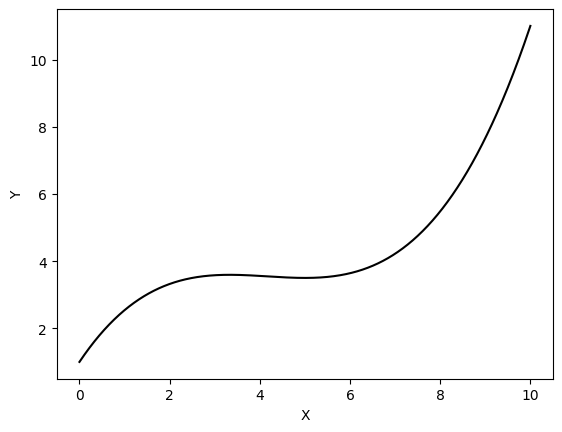

In [134]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
np.random.seed(0)
A = 1 
B = 2
C = -0.5
D = 0.04
x_true = np.linspace(0, 10, 1000).round(2)
y_true = A + B * x_true + C * x_true**2 + D * x_true**3

plt.plot(x_true, y_true, color="black")
plt.xlabel('X')
plt.ylabel('Y')

# Learning from data
The function that you plot above is ofcourse arbitrary, since you chose the coefficients of the polynomial. In fact the choice of a polynomial is also arbitrary (we chose it because it is easy to explain). But in reality this could have a certain meaning; a 1-D function could be a signal from a sensor, for instance a temperature sensor, or it could show how price of a house changes with time, etc. 
(Insert example of a 1-D signal relevant to biology, which is simple like a polynomial)

In reality, you will get only discrete data points from a sensor and you need to build a model from this data. The process of learning the function from a discrete set of points is called Machine Learning. Below, you can see a set of sampled points from the function that you generated above. The sampled points are in red, and the dashed line indicates the true function. 

      X          Y
0  9.94  10.762511
1  8.60   6.662240
2  2.98   3.578344
3  5.54   3.535459
4  6.73   4.006399


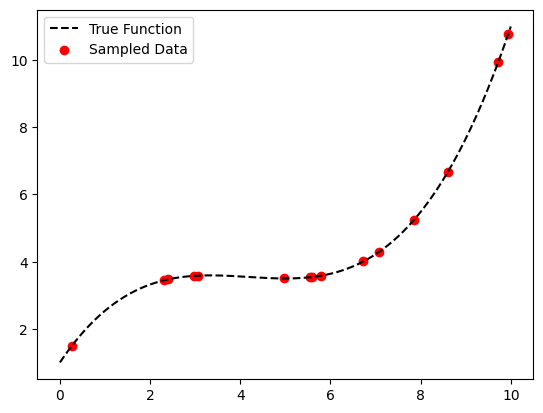

In [135]:
sample_size = 15
sampling_indices = np.random.choice(len(x_true), size=sample_size, replace=False)
x_sample = x_true[sampling_indices]
y_sample = y_true[sampling_indices] 

plt.plot(x_true, y_true, color="black", label="True Function", linestyle='--')
plt.scatter(x_sample, y_sample, color="red", label="Sampled Data")
plt.legend()

# show sampled points as a table 

data = {'X': x_sample, 'Y': y_sample}
df = pd.DataFrame(data)
print(df.head())

A direct method is ofcourse to use a polynomial function. We will use that method to fit the function first. Then, we will build a neural network from scratch and then fit those same datapoints. We will then discuss what the difference is between fitting a polynomial versus a neural network is. 

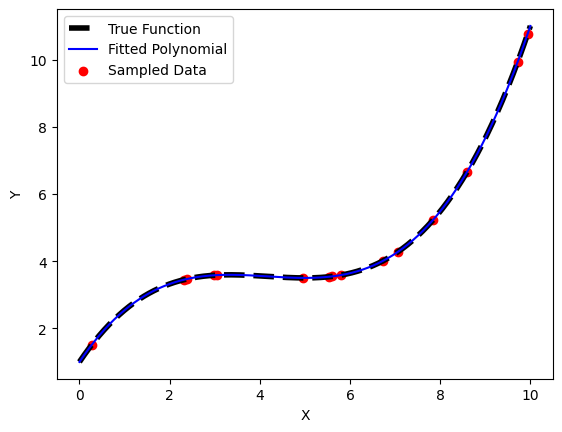

In [136]:
# Fitting a polynomial of degree 3 to the data
coefficients = np.polyfit(x_sample, y_sample, deg=3)
fitted_polynomial = np.poly1d(coefficients)
y_fitted = fitted_polynomial(x_true)
plt.plot(x_true, y_true, color="black", label="True Function", linestyle='--', linewidth=4)
plt.plot(x_true, y_fitted, color="blue", label="Fitted Polynomial")
plt.scatter(x_sample, y_sample, color="red", label="Sampled Data")
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()


# Learning through neurons

We will see in this module how the same function can be learnt through a different framework, one loosely inspired by the human brain. A neuron is simply a cell which takes some input and transforms into an output, and the comparison to biological neuron basically ends there. 

For biological neurons, the transformation of the input is generally described as a binary output (either it fires or not). This can be modelled as a sigmoid function, where the output slowly changes between 0 and 1 through an exponential change. 

A digital neuron can ofcourse be modelled by any mathematical function. Normally, this function is a non-linear function. The simplest non-linear function that is typically used is one which just produces a null output for all negative inputs, and returns the same input if it is positive. It is called a rectified linear function (ReLU). Run the code cell below to see the shape of the two functions 

TODO: Add an interactive cell here to show how neurons modify the input given an activation function

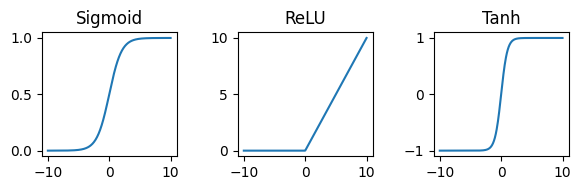

In [164]:
import matplotlib.pyplot as plt
import numpy as np
def activation_function(z, function_type="sigmoid"):
    if function_type == "sigmoid":
        return 1 / (1 + np.exp(-z))
    elif function_type == "relu":
        return np.maximum(0, z)
    elif function_type == "tanh":
        return np.tanh(z)
    elif function_type == "linear":
        return z
    else:
        raise ValueError("Unsupported activation function.")


# plot sigmoid and relu

z = np.linspace(-10, 10, 400)
sigmoid_values = activation_function(z, function_type="sigmoid")
relu_values = activation_function(z, function_type="relu")
tanh_values = activation_function(z, function_type="tanh")
fig, ax = plt.subplots(1, 3, figsize=(6, 2))
ax[0].plot(z, sigmoid_values)
ax[0].set_title("Sigmoid")
ax[1].plot(z, relu_values)
ax[1].set_title("ReLU")
ax[2].plot(z, tanh_values)
ax[2].set_title("Tanh")

plt.tight_layout()



Learning through a neuron network, simply amounts to finding a combination of activation functions which best approximates the dataset that you have provided. In contrast to fitting a polynomial, where you know the type of function that you are approximating, here the prior knowledge required is much less. As you will see, _any_ function can be approximated by a neural network, given enough neurons and layers. 

First, check out what parameters you can change for each activation function type. Let us stick to ReLu for now. 

In [138]:
# Add an interact to visualise effect of parameters on the neuron output
# Use ReLU, PReLU, sigmoid, and tanh as activation functions
import ipywidgets as widgets
def update_neuron_output(slope, bias):
    input = np.array([1])  # Example input
    # Plot the output
    x_global = np.linspace(-10, 10, 400)
    z = slope * x_global + bias
    y_global = activation_function(z, function_type="relu")
    plt.figure(figsize=(3, 3))
    plt.plot(x_global, y_global, label=f"Output")
    plt.plot(x_global, z, color="gray", linestyle='--', label=f"Linear function")
    plt.xlabel('Input (x)')
    plt.ylabel('Output (y)')
    plt.xlim(0, 10)
    plt.xticks(np.arange(-4, 11, 4))
    plt.yticks(np.arange(-5, 11, 5))
    plt.ylim(-5, 10)
    plt.legend()
    plt.title(f"Slope={slope:.2f}, Bias={bias:.2f}")
    
slope_slider = widgets.FloatSlider(min=0, max=5, step=0.1, value=1, description='Slope')
bias_slider = widgets.FloatSlider(min=-5, max=5, step=0.1, value=0, description='Bias')
widgets.interact(update_neuron_output, slope=slope_slider, bias=bias_slider)



interactive(children=(FloatSlider(value=1.0, description='Slope', max=5.0), FloatSlider(value=0.0, description…

<function __main__.update_neuron_output(slope, bias)>

See how the slope and the bias both affect the point at which the function starts to produce a non-zero output. Let us call this as the "activation point" (which is not exactly a technical term, but it is a useful one for our discussion).

Try the next cell to change the ReLU function using slope and activation point. 

In [139]:
# Add an interact to visualise effect of parameters on the neuron output
# Use ReLU, PReLU, sigmoid, and tanh as activation functions
import ipywidgets as widgets
def update_neuron_output_using_activation_point(slope, activation_point):
    input = np.array([1])  # Example input
    # Plot the output
    x_global = np.linspace(-10, 10, 400)
    # calculate bias from activation point
    bias = -slope * activation_point
    z = slope * x_global + bias
    y_global = activation_function(z, function_type="relu")
    plt.figure(figsize=(3, 3))
    plt.plot(x_global, y_global, label=f"Output")
    plt.plot(x_global, z, color="gray", linestyle='--', label=f"Linear function")
    plt.xlabel('Input (x)')
    plt.ylabel('Output (y)')
    plt.xlim(0, 10)
    plt.xticks(np.arange(-4, 11, 4))
    plt.ylim(-5, 10)
    # vertical line at activation point until it hits the bias value
    plt.scatter(0, bias)
    plt.plot([-4, 0], [bias, bias], color="red", linestyle='--')
    # add bias value as y tick
    plt.yticks([-5.0, 0.0, 5.0, 10.0, bias])
    # round off 1 decimal for ytick label
    plt.yticks([-5.0, 0.0, 5.0, 10.0, bias], [f"{-5:.1f}", f"{0:.1f}", f"{5:.1f}", f"{10:.1f}", f"{bias:.1f}"])
    


    plt.legend()
    plt.title(f"Slope={slope:.2f}, Bias={bias:.2f}")
    plt.tight_layout()
    
slope_slider = widgets.FloatSlider(min=0, max=5, step=0.1, value=1, description='Slope')
activation_point_slider = widgets.FloatSlider(min=0, max=8, step=0.1, value=0, description='Activation point')
widgets.interact(update_neuron_output_using_activation_point, slope=slope_slider, activation_point=activation_point_slider)



interactive(children=(FloatSlider(value=1.0, description='Slope', max=5.0), FloatSlider(value=0.0, description…

<function __main__.update_neuron_output_using_activation_point(slope, activation_point)>

Now, combine three ReLU neurons together to see how they can approximate a more complex function. Use activation point, slope and weights to change the shape of the function.

In [140]:
def update_layer_of_neurons_using_slope_activation_point(slope_1, slope_2, slope_3, activation_point_1, activation_point_2, activation_point_3, weight_1, weight_2, weight_3, output_bias):
    # calculate bias from activation points for each neuron
    bias_1 = -slope_1 * activation_point_1
    bias_2 = -slope_2 * activation_point_2
    bias_3 = -slope_3 * activation_point_3
    # combined output
    x_global = np.linspace(-10, 10, 1000)
    z_1_global = slope_1 * x_global + bias_1
    z_2_global = slope_2 * x_global + bias_2
    z_3_global = slope_3 * x_global + bias_3
    y_1_global = activation_function(z_1_global, function_type="relu")
    y_2_global = activation_function(z_2_global, function_type="relu")
    y_3_global = activation_function(z_3_global, function_type="relu")

    combined_output = weight_1 * y_1_global + weight_2 * y_2_global + weight_3 * y_3_global + output_bias
    x_global_true = np.linspace(0, 10, 1000)
    y_1_global_true = activation_function(slope_1 * x_global_true + bias_1, function_type="relu")
    y_2_global_true = activation_function(slope_2 * x_global_true + bias_2, function_type="relu")
    y_3_global_true = activation_function(slope_3 * x_global_true + bias_3, function_type="relu")
    combined_output_true = weight_1 * y_1_global_true + weight_2 * y_2_global_true + weight_3 * y_3_global_true + output_bias

    fig, ax = plt.subplots(1, 4, figsize=(12, 3))
    ax[0].plot(x_global, y_1_global, label=f"Neuron 1 Output")
    ax[0].set_title(f"Neuron 1\nSlope={slope_1:.2f}, Bias={bias_1:.2f}")
    ax[0].set_xlabel('Input (x)')
    ax[0].set_ylabel('Output (y)')
    ax[0].legend()
    ax[0].set_xlim(-4, 10)
    ax[0].set_xticks(np.arange(-4, 11, 4))
    ax[0].set_ylim(-5, 10)
    ax[0].set_yticks(np.arange(-5, 11, 5))
    ax[1].plot(x_global, y_2_global, label=f"Neuron 2 Output")
    ax[1].set_title(f"Neuron 2\nSlope={slope_2:.2f}, Bias={bias_2:.2f}")
    ax[1].set_xlabel('Input (x)')
    # hide y axis for ax[1]
    ax[1].set_ylim(-5, 10)
    ax[1].set_yticks([])
    ax[1].legend()
    ax[1].set_xlim(0, 10)
    ax[1].set_xticks(np.arange(-4, 11, 4))
    ax[2].plot(x_global, y_3_global, label=f"Neuron 3 Output")
    ax[2].set_title(f"Neuron 3\nSlope={slope_3:.2f}, Bias={bias_3:.2f}")
    ax[2].set_xlabel('Input (x)')
    # hide y axis for ax[2]
    ax[2].set_ylim(-5, 10)
    ax[2].set_yticks([])
    ax[2].legend()
    ax[2].set_xlim(0, 10)
    ax[2].set_xticks(np.arange(-4, 11, 4))
    ax[3].plot(x_global, combined_output, label=f"Combined Output")
    ax[3].plot(x_true, y_true, color="black", label="True Function", linestyle='--', linewidth=2)
    ax[3].set_title(f"Combined Output")
    ax[3].set_xlabel('Input (x)')
    # hide y axis for ax[3]
    ax[3].set_ylim(-5, 10)
    ax[3].set_yticks([])
    ax[3].legend()
    ax[3].set_xlim(0, 10)
    ax[3].set_xticks(np.arange(0, 11, 2))

    # compute mean squared error between combined output and true function at the sampled points
    
    mean_squared_error = np.mean((combined_output_true - y_true)**2)
    plt.suptitle(f"Mean Squared Error: {mean_squared_error:.2f}")
    plt.tight_layout()

In [141]:
slopes = [widgets.FloatSlider(min=-5, max=5, step=0.1, value=0, description='Slope 1'),
          widgets.FloatSlider(min=-5, max=5, step=0.1, value=0, description='Slope 2'),
          widgets.FloatSlider(min=-5, max=5, step=0.1, value=0, description='Slope 3')]
activation_points = [widgets.FloatSlider(min=0, max=8, step=0.1, value=0, description='Activation point 1'),
                     widgets.FloatSlider(min=0, max=8, step=0.1, value=0, description='Activation point 2'),
                     widgets.FloatSlider(min=0, max=8, step=0.1, value=0, description='Activation point 3')]
weights = [widgets.FloatSlider(min=-5, max=5, step=0.1, value=1, description='Weight 1'),
              widgets.FloatSlider(min=-5, max=5, step=0.1, value=1, description='Weight 2'),
              widgets.FloatSlider(min=-5, max=5, step=0.1, value=1, description='Weight 3')]

output_bias = widgets.FloatSlider(min=-5, max=5, step=0.1, value=0, description='Output Bias')
widgets.interact(update_layer_of_neurons_using_slope_activation_point, \
                 slope_1=slopes[0], slope_2=slopes[1], slope_3=slopes[2], \
                 activation_point_1=activation_points[0], activation_point_2=activation_points[1], activation_point_3=activation_points[2], \
                 weight_1=weights[0], weight_2=weights[1], weight_3=weights[2], output_bias=output_bias)


interactive(children=(FloatSlider(value=0.0, description='Slope 1', max=5.0, min=-5.0), FloatSlider(value=0.0,…

<function __main__.update_layer_of_neurons_using_slope_activation_point(slope_1, slope_2, slope_3, activation_point_1, activation_point_2, activation_point_3, weight_1, weight_2, weight_3, output_bias)>

Could you get a good fit? Could you get the error to be less than 1? What about 0.1? or even 0.01 or zero?

## Think! 
- Why do you think three neurons were sufficient for this curve? 
- What would happen if you had only two neurons? What if you have a million neurons?


# Artificial Neural Networks

In biological neurons, the connection strengths between the cells are modulated by complex biochemical processes. In artificial neurons, the connection strength is simply a number, which we call a weight. The weight can be positive or negative, and it determines how much influence the input has on the output of the neuron. Each neuron performs a linear combination of the inputs with the weights and then applies the non-linear activation function before sending the output to the next layer of neurons. Mathematically, the output of a single neuron can be expressed as:

\begin{equation}
y = f\left(\sum_{i=1}^{n} w_i x_i + b\right)
\end{equation}

Where:
- $x_i$ are the inputs to the neuron
- $w_i$ are the weights associated with each input, similar to the slope that you just played with
- $b$ is the bias term, which shifts the activation point of the function along with the weights
- $f$ is the activation function (e.g., ReLU, sigmoid)
- $y$ is the output of the neuron

Now, build this equation into a function. 


In [142]:
def neuron(x_input, weight, bias, activation_function_type="sigmoid"):
    z = np.dot(x_input, weight) + bias
    output = activation_function(z, function_type=activation_function_type)
    return output

x_input = np.array([x_sample[0], x_sample[1], x_sample[2], x_sample[3], x_sample[4]])  # Example input from sampled data earlier
weights = np.array([0.5, 0.2, 0, 0.3, 4])  # Weights for inputs, assuming 5 inputs for the neuron. 
biases = np.array([0.1])  # A single bias applied to the neuron output

output = neuron(x_input, weights, biases, activation_function_type="relu")
print("Output of the neuron:", output)



Output of the neuron: [35.372]


To understand how a neuron "adapts", let us first build a layer of neurons. 


In [157]:
def layer(**neurons):
    layer_output = {}
    for neuron_name, neuron_params in neurons.items():
        input = neuron_params['x_input']
        weight = neuron_params['weight']
        bias = neuron_params['bias']
        activation_function_type = neuron_params['activation_function_type']
        output = neuron(input, weight, bias, activation_function_type=activation_function_type)
        layer_output[neuron_name] = output
    return layer_output

In [158]:
# Create a layer with 3 neurons getting one input. Start with the first input point from the sampled data. 
input_vector = [x_sample[0]]
output_vector = [y_sample[0]]
print(f"The input is {input_vector} and the expected output is {output_vector}")

The input is [9.94] and the expected output is [10.762511360000001]


The first layer has three neurons. Each neurons need to know how much to weigh the input and what bias to apply. For now, give a random weight and bias to each neuron.

In [159]:

weight_vector = np.array([0.5, 0.2, 0])  # Weights for each neuron
bias_vector = np.array([0.1, 0.2, 0.3])  # Biases for each neuron
activation_function_string = "sigmoid"

layer_output = layer(
    neuron1={
        'x_input': input_vector,
        'weight': weight_vector[0],
        'bias': bias_vector[0],
        'activation_function_type': activation_function_string
    },
    neuron2={
        'x_input': input_vector,
        'weight': weight_vector[1],
        'bias': bias_vector[1],
        'activation_function_type': activation_function_string
    },
    neuron3={
        'x_input': input_vector,
        'weight': weight_vector[2],
        'bias': bias_vector[2],
        'activation_function_type': activation_function_string
    }
)

print("Output of the layer:", layer_output)

Output of the layer: {'neuron1': array([0.9937568]), 'neuron2': array([0.89916672]), 'neuron3': array([0.57444252])}


Now, we need to combine these neurons into a single output neuron. This will be our final layer. Here, we have one neuron which takes three inputs, which are the outputs of the three neurons in the previous layer. It's weights and bias will determine how much influence each of the three neurons has on the final output.


In [165]:
last_layer_weights = np.array([0.2, -0.4, 0.6])
last_layer_bias = 0.1

last_layer_output = layer(
    output_neuron = {
        'x_input': np.array(list(layer_output.values())).reshape(-1),  # Convert layer output to a numpy array
        'weight': last_layer_weights,
        'bias': last_layer_bias,
        'activation_function_type': "linear"
    }
)

print(f"Final output of the network: {last_layer_output['output_neuron']}. Expected output: {output_vector}")




Final output of the network: 0.2837501828236447. Expected output: [10.762511360000001]


Is there a lot of error? Well, that is life... We will now start learning how to correct our mistakes! As in life, the first step is to acknowledge the error. In deep learning, we do it with something called as a "loss function". It tells you how far your predictions are from the expected outcome. 

In case of regression problems (like the one we are working on), a common loss function is the Mean Squared Error (MSE), which is calculated as:
\begin{equation}
MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
\end{equation}
Where:
- $y_i$ are the true values
- $\hat{y}_i$ are the predicted values from the neural network
- $n$ is the number of data points in the output
There are other loss functions as well. Try to implement the MSE loss function and calculate the loss for your current model.


In [166]:
# Compute the loss 
def mean_squared_error(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

In [167]:
loss_value = mean_squared_error(output_vector, last_layer_output['output_neuron'])
print("Loss value:", loss_value)

Loss value: 109.80443580829841


It's great that you now know exactly how wrong you were! Now, time to correct it. 

# Backpropagation

Here, we calculate the gradient of the loss function with respect to each weights and bias in the neural network. This might seem complicated because there are many parameters. However, we will how the chain rule of calculus comes in handy. 

But first, we will start with a simpler problem. We will calculate the derivative of the loss function with respect to the final output of the network. This is the first step in backpropagation. First, recap the equation for the MSE for a single data point:


\begin{equation}
MSE = (y_i - \hat{y}_i)^2
\end{equation}


\begin{equation}
\frac{\partial MSE}{\partial \hat{y}_{final}} = -2(y_i - \hat{y}_i)
\end{equation}


In [168]:
def gradient_mse(y_true, y_pred):
    return 2 * (y_pred - y_true) / len(y_true)

gradient_value = gradient_mse(output_vector, last_layer_output['output_neuron'])
print("Gradient of the loss with respect to the output:", gradient_value)

Gradient of the loss with respect to the output: [-20.95752235]


Updated weights: [ 0.2489208  -0.39202321  0.6489208 ]
Updated bias: [0.16691775]


In [31]:
# Show the updated output after one step of gradient descent
updated_final_output = neuron(
    input=np.array(list(layer_output.values())).reshape(-1),
    weight=updated_weights,
    bias=updated_bias,
    activation_function_type="sigmoid"
)
print("Updated final output:", updated_final_output)



Updated final output: [0.68493872]


In [32]:
# Updated loss after one step of gradient descent
updated_loss_value = loss_function(predicted=updated_final_output, actual=output_vector, function_type="mse")
print("Updated Loss value:", updated_loss_value)
print("Original Loss value:", loss_value)
print("Loss reduction:", loss_value - updated_loss_value)

Updated Loss value: 10.989631260244353
Original Loss value: 11.194963288681038
Loss reduction: 0.2053320284366844


Text(0.5, 1.0, 'Effect of Learning Rate on Loss')

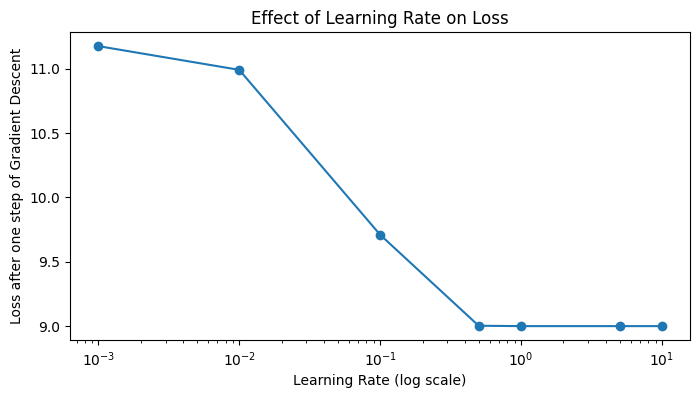

In [36]:
learning_rate_values = [0.001, 0.01, 0.1, 0.5, 1.0, 5.0, 10]
loss_for_learning_rates = []

# What was the loss for each learning rate after one step of gradient descent?
for lr in learning_rate_values:
    updated_weights = last_layer_weights - lr * gradient_value * np.array(list(layer_output.values())).reshape(-1)
    updated_bias = last_layer_bias - lr * gradient_value
    updated_final_output = neuron(
        input=np.array(list(layer_output.values())).reshape(-1),
        weight=updated_weights,
        bias=updated_bias,
        activation_function_type="sigmoid"
    )
    updated_loss = loss_function(predicted=updated_final_output, actual=output_vector, function_type="mse")
    loss_for_learning_rates.append(updated_loss)

plt.figure(figsize=(8, 4))
plt.plot(learning_rate_values, loss_for_learning_rates, marker='o')
plt.xscale('log')
plt.xlabel('Learning Rate (log scale)')
plt.ylabel('Loss after one step of Gradient Descent')
plt.title('Effect of Learning Rate on Loss')
